In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

gender = pd.read_csv('gender_submission.csv')
test = pd.read_csv('test.csv') 
train = pd.read_csv('train.csv')

## Exercice 1

In [10]:
train_copy = train.copy()

# Identifions les doublons
nb_doublons = train_copy.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

# Supprimons les doublons
tr_length_before = len(train_copy)
train_copy = train_copy.drop_duplicates()
tr_length_after = len(train_copy)
print(f"Nombre de lignes supprimées : {tr_length_before - tr_length_after}")

Nombre de doublons : 0
Nombre de lignes supprimées : 0


## Exercice 2

Nombre de valeurs manquantes par colonne :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


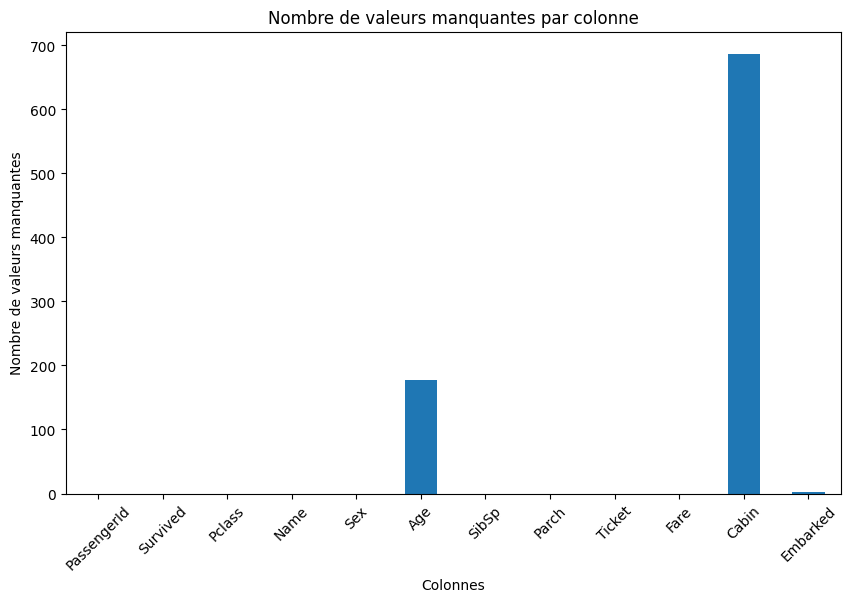

In [11]:
# Let's identify the missing values
missing_values = train_copy.isnull().sum()
missing_values_percent = (missing_values / len(train_copy)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percent})
print("Nombre de valeurs manquantes par colonne :")
print(missing_values)

# Let's visualize the missing values
plt.figure(figsize=(10, 6))
missing_values.plot(kind='bar')
plt.title('Nombre de valeurs manquantes par colonne')
plt.xlabel('Colonnes')
plt.ylabel('Nombre de valeurs manquantes')
plt.xticks(rotation=45)
plt.show()

In [12]:
# 2-Treatment strategy
# Strategy A – Age: imputation by the median (continuous value, skewed distribution)

imputer_median = SimpleImputer(strategy='median')
train['Age'] = imputer_median.fit_transform(train[['Age']])
print("Missing values ​​after imputation of the 'Age' column :")
print(f"{train['Age'].median():.1f} years")

# Strategy B – Embarked: imputation by mode (categorical variable, few missing values)

mode_embarked = train['Embarked'].mode()[0]
train['Embarked'] = train['Embarked'].fillna(mode_embarked)
print(f"Most common value for 'Embarked' : {mode_embarked}")

# Strategy C – Cabin: column removal (>77% of values ​​missing)

train = train.drop(columns=['Cabin'])
print("Column 'Cabin' removed.")

# Final verification of the missing values
final_missing_values = train.isnull().sum()
if final_missing_values.sum() == 0:
    print("All missing values have been treated.")
else:
    print("Number of missing values ​​per column after processing :")
    print(final_missing_values)



Missing values ​​after imputation of the 'Age' column :
28.0 years
Most common value for 'Embarked' : S
Column 'Cabin' removed.
All missing values have been treated.


## Exercice 3

Family size feature created.
Family size category feature created.
Title feature created and rare titles grouped.
Title feature encoded.
Title mapping : {'Master': np.int64(0), 'Miss': np.int64(1), 'Mr': np.int64(2), 'Mrs': np.int64(3), 'Rare': np.int64(4)}


<>:13: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:13: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\meles\AppData\Local\Temp\ipykernel_23040\554282518.py:13: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False).str.strip()
C:\Users\meles\AppData\Local\Temp\ipykernel_23040\554282518.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


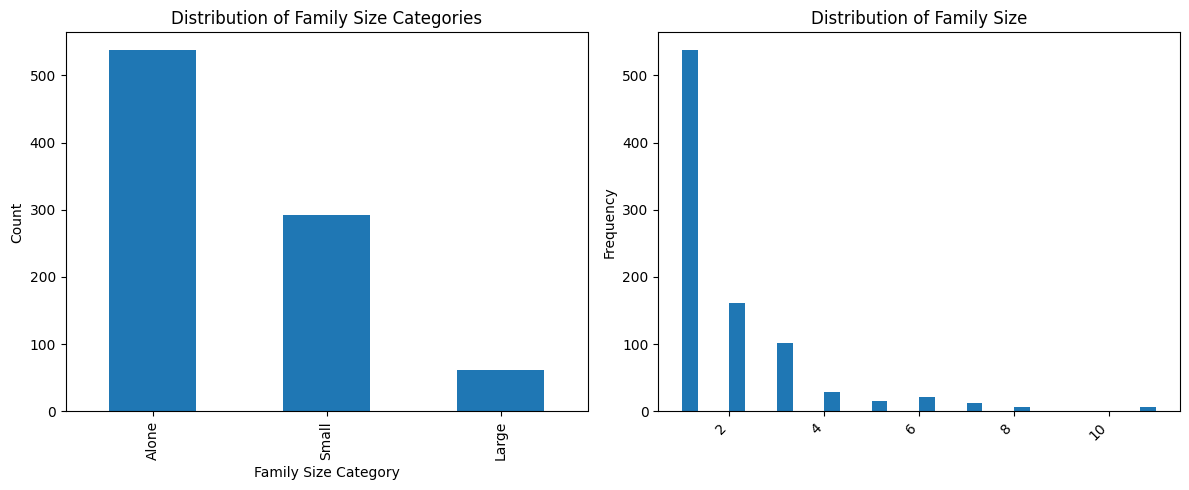

In [13]:
# 1--Family size = SibSp + Parch + 1

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
print("Family size feature created.")

# Family size Cateagory
train['FamilySizeCategory'] = train['FamilySize'].apply(
    lambda x: 'Alone' if x == 1 else ('Small' if x <= 4 else 'Large')
    )
print("Family size category feature created.")

# 2-- Title extraction from the 'Name' column
train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False).str.strip()

# Grouping rare titles 
rare_titles = train['Title'].value_counts()
rare_titles = rare_titles[rare_titles < 10].index
train['Title'] = train['Title'].replace(rare_titles, 'Rare')
print("Title feature created and rare titles grouped.")

# 3-- Title encoding
title_mapping = LabelEncoder()
train['Title'] = title_mapping.fit_transform(train['Title'])
print("Title feature encoded.")
print(f"Title mapping : {dict(zip(title_mapping.classes_, title_mapping.transform(title_mapping.classes_)))}")

# Visualization of family size distribution
figs, axes = plt.subplots(1, 2, figsize=(12, 5))
#sns.countplot(x='FamilySizeCategory', data=train, ax=axes[0])
train['FamilySizeCategory'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribution of Family Size Categories')
axes[0].set_xlabel('Family Size Category')
axes[0].set_ylabel('Count')

train['FamilySize'].plot(kind='hist', bins=30, ax=axes[1])
axes[1].set_title('Distribution of Family Size')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Exercice 4

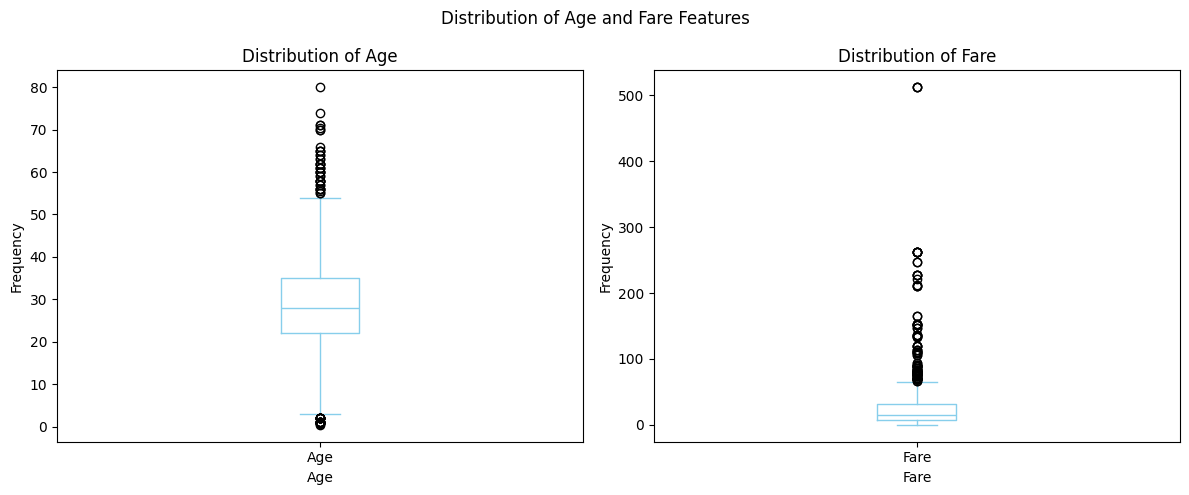

Age - Lower bound: 2.50, Upper bound: 54.50, Number of outliers: 66
Fare - Lower bound: -26.72, Upper bound: 65.63, Number of outliers: 116
Age capped at 98th percentile: 62.00 years (quartile 0.98)
Fare feature log-transformed.


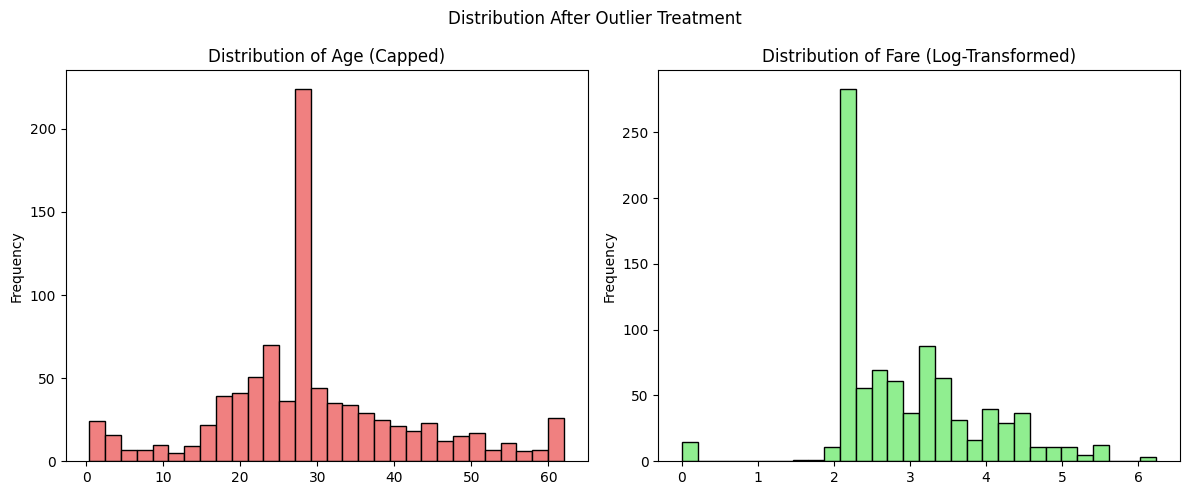

Original 'Age' and 'Fare' columns replaced with treated versions.


In [19]:
# 1--Initial visualisation 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution of Age and Fare Features')

for i, col in enumerate(['Age', 'Fare']):
    train[col].plot(kind='box', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# 2-- IQR detection
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

for col in ['Age', 'Fare']:
    outliers = detect_outliers_iqr(train[col])
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{col} - Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}, Number of outliers: {len(outliers)}")

# 3-- Treatment of outliers
# Age -> Capping to 98th quartile
age_upper_cap = train['Age'].quantile(0.98)
train['Age_capped'] = train['Age'].clip(upper=age_upper_cap)
print(f"Age capped at 98th percentile: {age_upper_cap:.2f} years (quartile 0.98)")

# Fare -> Log transformation (highly asymmetrical distribution)
train['Fare_log'] = np.log1p(train['Fare'])
print("Fare feature log-transformed.")

# Visualization after outlier treatment
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribution After Outlier Treatment')
train['Age_capped'].plot(kind='hist', bins=30, ax=axes[0], color='lightcoral', edgecolor='black')
axes[0].set_title('Distribution of Age (Capped)')
train['Fare_log'].plot(kind='hist', bins=30, ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Fare (Log-Transformed)')

plt.tight_layout()
plt.show()

# Replacement of the original columns
train['Age'] = train['Age_capped']
train['Fare'] = train['Fare_log']
train.drop(columns=['Age_capped', 'Fare_log'], inplace=True)
print("Original 'Age' and 'Fare' columns replaced with treated versions.")

## Exercice 5

Standard scaling applied to 'Age' column.
Min-Max scaling applied to 'Fare', 'FamilySize', and 'PClass' columns.


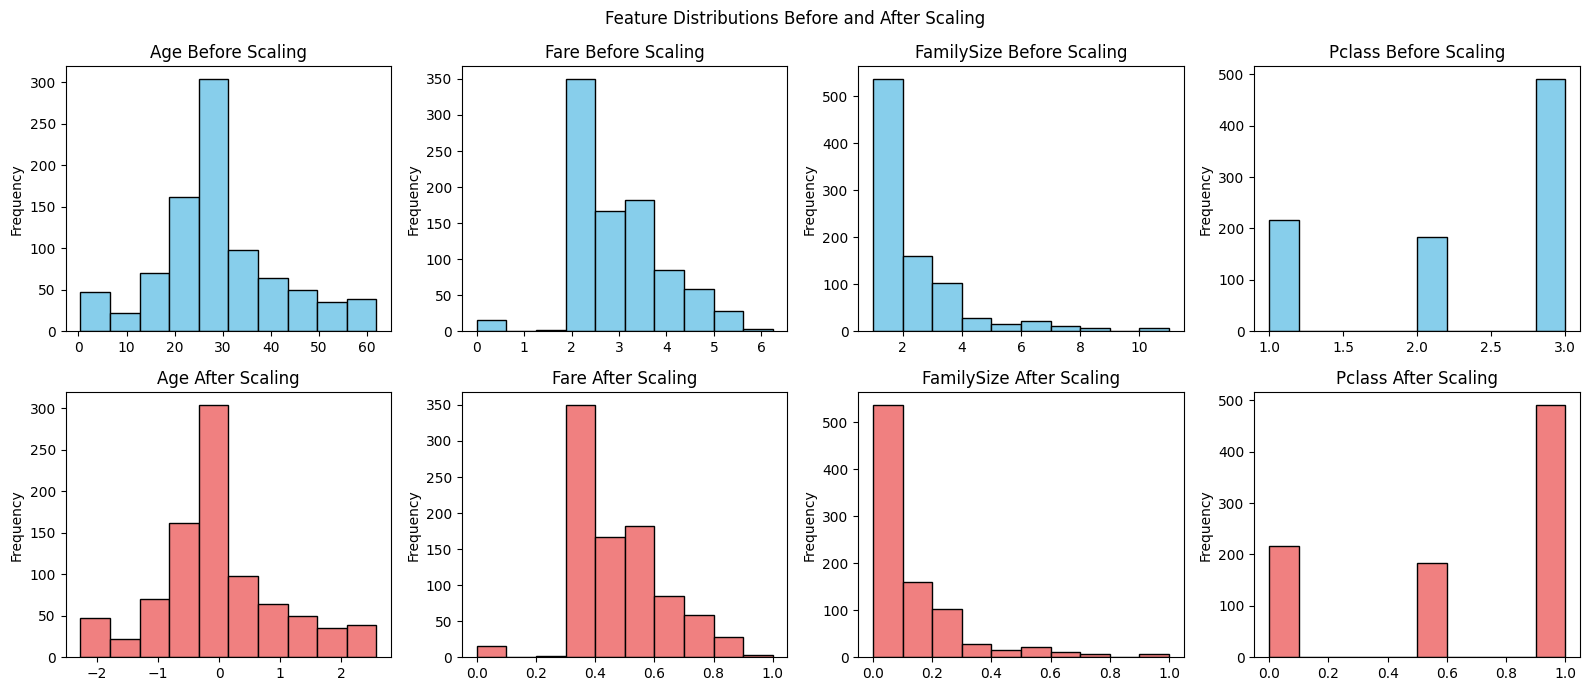

Statistics after scaling :


,Age,Fare,FamilySize,Pclass
count,891.0000,891.0000,891.0000,891.0000
mean,0.0000,0.4746,0.0905,0.6543
std,1.0006,0.1553,0.1613,0.4180
min,-2.2685,0.0000,0.0000,0.0000
25%,-0.5710,0.3505,0.0000,0.5000
50%,-0.0990,0.4387,0.0000,1.0000
75%,0.4516,0.5553,0.1000,1.0000
max,2.5754,1.0000,1.0000,1.0000


In [21]:
cols_standard = ['Age']
cols_minmax = ['Fare', 'FamilySize', 'Pclass']

train_before_scaling = train[cols_standard + cols_minmax].copy()

# Standard scaling for 'Age' (as it is a continuous variable with a more normal distribution)
scaler_standard = StandardScaler()
train[cols_standard] = scaler_standard.fit_transform(train[cols_standard])
print("Standard scaling applied to 'Age' column.")

# Min-Max scaling for 'Fare', 'FamilySize', and 'PClass' (as they have different scales and distributions)
scaler_minmax = MinMaxScaler()
train[cols_minmax] = scaler_minmax.fit_transform(train[cols_minmax])
print("Min-Max scaling applied to 'Fare', 'FamilySize', and 'PClass' columns.")

# Visualization after scaling
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle('Feature Distributions Before and After Scaling')

all_cols = cols_standard + cols_minmax
for i, col in enumerate(all_cols):
    train_before_scaling[col].plot(kind='hist', ax=axes[0, i], color='skyblue', edgecolor='black')
    axes[0, i].set_title(f'{col} Before Scaling')
    train[col].plot(kind='hist', ax=axes[1, i], color='lightcoral', edgecolor='black')
    axes[1, i].set_title(f'{col} After Scaling')

plt.tight_layout()
plt.show()

print("Statistics after scaling :")
display(train[all_cols].describe().round(4))

## Exercice 6

In [23]:
# 1-Remaining categorical variables
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f"Remaining categorical columns : {categorical_cols}")

# 2-One-Hot Encoding pour Sex, Embarked, FamilyCategory
cols_to_encode = ['Sex', 'Embarked', 'FamilySizeCategory']
train_encoded = pd.get_dummies(train, columns=cols_to_encode, drop_first=True)
print(f"One-Hot Encoding applied to {cols_to_encode} columns.")

# 3-Merge with the main DataFrame
train = train.drop(columns=cols_to_encode)  # Drop original columns
train = pd.concat([train, train_encoded], axis=1)  # Merge encoded columns

# Drop columns that are not useful for modeling
train = train.drop(columns=['Name', 'Ticket', 'Title'], inplace=False, errors='ignore')  # Drop 'Title' as it has been encoded

print("Final dataset ready for modeling. Shape:", train.shape)
display(train.head(3))

Remaining categorical columns : ['Name', 'Sex', 'Ticket', 'Embarked', 'FamilySizeCategory']
One-Hot Encoding applied to ['Sex', 'Embarked', 'FamilySizeCategory'] columns.
Final dataset ready for modeling. Shape: (891, 21)


C:\Users\meles\AppData\Local\Temp\ipykernel_23040\891178061.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include=['object']).columns.tolist()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,PassengerId,Survived,...,Age,SibSp,Parch,Fare,FamilySize,Sex_male,Embarked_Q,Embarked_S,FamilySizeCategory_Large,FamilySizeCategory_Small
0,1,0,1.0,-0.570988,1,0,0.338125,0.1,1,0,...,-0.570988,1,0,0.338125,0.1,True,False,True,False,True
1,2,1,0.0,0.687580,1,0,0.685892,0.1,2,1,...,0.687580,1,0,0.685892,0.1,False,False,False,False,True
2,3,1,1.0,-0.256346,0,0,0.350727,0.0,3,1,...,-0.256346,0,0,0.350727,0.0,False,False,True,False,False


## Exercice 7

Age discretized into categories :
Age
Child        69
Teenager     70
Adult       535
Senior      195
Elderly      22
Name: count, dtype: int64
One-Hot Encoding applied to discretized age categories.
   AgeGroup_Child  AgeGroup_Teenager  AgeGroup_Adult  AgeGroup_Senior  \
0               0                  0               1                0   
1               0                  0               0                1   
2               0                  0               1                0   
3               0                  0               1                0   
4               0                  0               1                0   

   AgeGroup_Elderly  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  
Encoded age group features added to the dataset (only new columns).
Final dataset with encoded age groups. Shape: (891, 26)


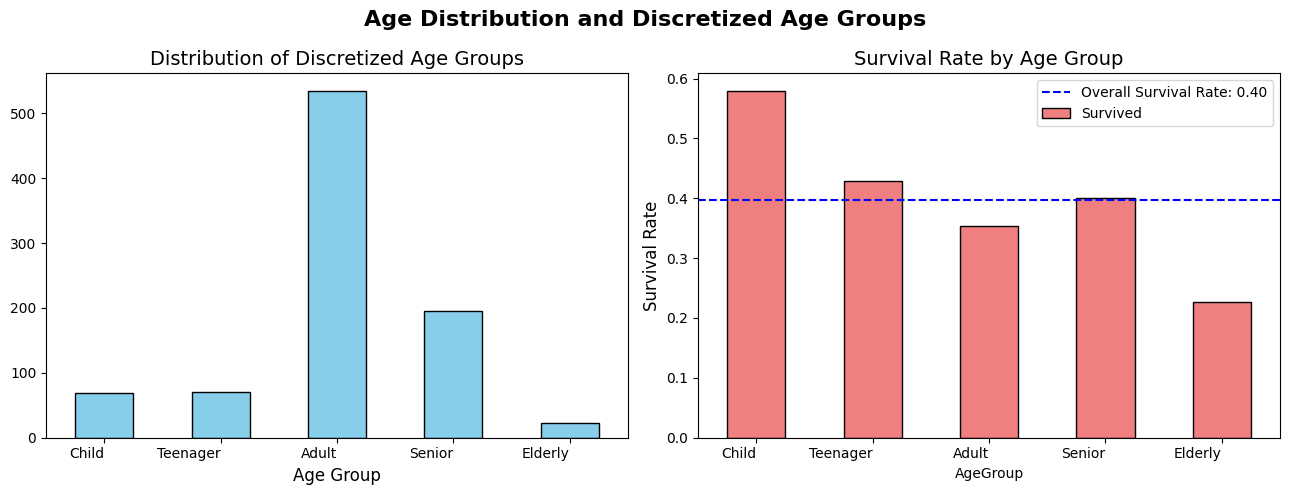

In [26]:
age_original = train_copy['Age'].copy()

age_original = age_original.fillna(age_original.median())

# 1-Discretization with pd.cut()
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teenager', 'Adult', 'Senior', 'Elderly']

age_discretized = pd.cut(age_original, bins=age_bins, labels=age_labels)
print("Age discretized into categories :")
print(age_discretized.value_counts().sort_index())

# 2-One-Hot Encoding of the discretized age categories
age_encoded = pd.get_dummies(age_discretized, prefix='AgeGroup', drop_first=False, dtype=int)
print("One-Hot Encoding applied to discretized age categories.")
print(age_encoded.head(5))

# 3-Adding the encoded age groups to the original DataFrame
# Add only missing encoded columns to avoid creating duplicate/2D columns
for col in age_encoded.columns:
	if col not in train.columns:
		train[col] = age_encoded[col].values
print("Encoded age group features added to the dataset (only new columns).")
print("Final dataset with encoded age groups. Shape:", train.shape)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Age Distribution and Discretized Age Groups', fontsize=16, fontweight='bold')

age_discretized.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Discretized Age Groups', fontsize=14)
axes[0].set_xlabel('Age Group', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='right')

# Ensure 'Survived' is a 1-D series (in case of duplicate column names it could be a DataFrame)
surv = train['Survived']
if isinstance(surv, pd.DataFrame):
	surv = surv.iloc[:, 0]

survival_by_age_group = pd.DataFrame({'AgeGroup': age_discretized.values, 'Survived': surv.values})
survival_rate = survival_by_age_group.groupby('AgeGroup')['Survived'].mean()
survival_rate.plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Survival Rate by Age Group', fontsize=14)
axes[1].set_ylabel('Survival Rate', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha='right')
axes[1].axhline(survival_rate.mean(), color='blue', linestyle='--', label=f'Overall Survival Rate: {survival_rate.mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()
